# Exercises and Self Study on Link Prediction with Structural Similarity

Here are some imports for working with graphs.
Please also note, that some datastructures are given by the used return type from a library function. My selection of a datatype is arbutrary. Please feel free to optimize.

In [147]:
import networkx as ntx # networkX library for working with graphs
import numpy as np #numpy with some math and linear algebra
import pandas as pd #data frames for working with tabular data
import scipy # library for scientific computing
import random # library for randomly sampling from data
import math # math functions such as sqrt

In [148]:
random.seed(1123) # fixing the seed to always get the same random sample - important for repeating experiments

In [149]:
zachary = ntx.karate_club_graph() #importing karate club network

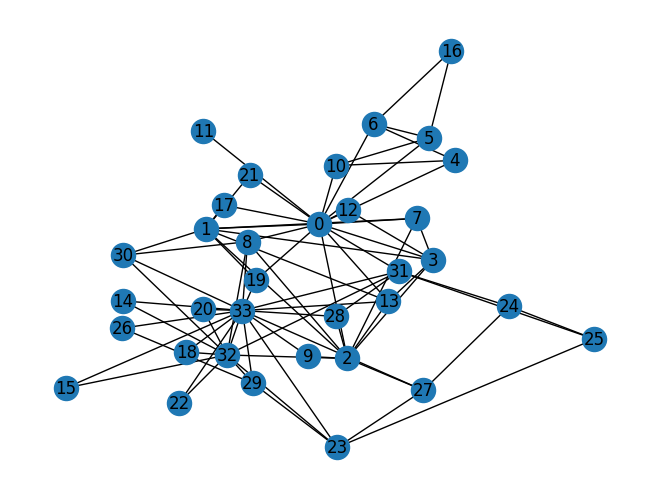

In [150]:
ntx.draw_kamada_kawai(zachary, with_labels=True) # drawing the network

NetworkX library function for link prediction based on Jaccard Similarity. Note, that it only computes the similarity for missing links

In [151]:
Jacard = ntx.jaccard_coefficient(zachary) 

Printing the results - it is in tuples

In [152]:
for tup in Jacard:
    print(tup)

(0, 32, 0.12)
(0, 33, 0.13793103448275862)
(0, 9, 0.058823529411764705)
(0, 14, 0.0)
(0, 15, 0.0)
(0, 16, 0.125)
(0, 18, 0.0)
(0, 20, 0.0)
(0, 22, 0.0)
(0, 23, 0.0)
(0, 24, 0.05555555555555555)
(0, 25, 0.05555555555555555)
(0, 26, 0.0)
(0, 27, 0.05263157894736842)
(0, 28, 0.11764705882352941)
(0, 29, 0.0)
(0, 30, 0.1111111111111111)
(1, 4, 0.09090909090909091)
(1, 5, 0.08333333333333333)
(1, 6, 0.08333333333333333)
(1, 8, 0.2727272727272727)
(1, 9, 0.1)
(1, 10, 0.09090909090909091)
(1, 11, 0.1111111111111111)
(1, 12, 0.2222222222222222)
(1, 14, 0.0)
(1, 15, 0.0)
(1, 16, 0.0)
(1, 18, 0.0)
(1, 20, 0.0)
(1, 22, 0.0)
(1, 23, 0.0)
(1, 24, 0.0)
(1, 25, 0.0)
(1, 26, 0.0)
(1, 27, 0.08333333333333333)
(1, 28, 0.09090909090909091)
(1, 29, 0.0)
(1, 31, 0.07142857142857142)
(1, 32, 0.10526315789473684)
(1, 33, 0.13043478260869565)
(2, 4, 0.08333333333333333)
(2, 5, 0.07692307692307693)
(2, 6, 0.07692307692307693)
(2, 10, 0.08333333333333333)
(2, 11, 0.1)
(2, 12, 0.2)
(2, 14, 0.09090909090909091)
(

If we want the such similarities to be available for all the nodes, they need to be computed

In [153]:
rows = sum(1 for _ in zachary.nodes())
cols = sum(1 for _ in zachary.nodes())

# VS - Vertex Similarity, JS - Jaccard Similarity, CosS - Cosine Similarity

VS = [[0 for _ in range(cols)] for _ in range(rows)]
JS = [[0 for _ in range(cols)] for _ in range(rows)]
CosS = [[0 for _ in range(cols)] for _ in range(rows)]

for u in zachary.nodes():
    for v in zachary.nodes():

        count_neighbrs_u = sum(1 for _ in ntx.neighbors(zachary, u))
        count_neighbrs_v = sum(1 for _ in ntx.neighbors(zachary, v))
        # getting a union of two lists with only unique values - used in Jaccard Sim.
        union_neighbors_u_v = list(set(list(ntx.neighbors(zachary, u)) + list(ntx.neighbors(zachary, v))))
        count_common_neighbors_uv = sum(1 for _ in ntx.common_neighbors(zachary,u, v))
        VS[u][v] = count_common_neighbors_uv
        JS[u][v] = count_common_neighbors_uv/len(union_neighbors_u_v)
        CosS [u][v] = count_common_neighbors_uv/math.sqrt(count_neighbrs_v * count_neighbrs_u)

print("Vertex Similarity: ")
print(VS)

Vertex Similarity: 
[[16, 7, 5, 5, 2, 2, 2, 3, 1, 1, 2, 0, 1, 3, 0, 0, 2, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 2, 0, 2, 0, 3, 4], [7, 9, 4, 4, 1, 1, 1, 3, 3, 1, 1, 1, 2, 3, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 2, 3], [5, 4, 10, 4, 1, 1, 1, 3, 2, 0, 1, 1, 2, 3, 1, 1, 0, 2, 1, 2, 1, 2, 1, 2, 1, 0, 0, 0, 0, 1, 3, 3, 1, 6], [5, 4, 4, 6, 1, 1, 1, 3, 2, 1, 1, 1, 1, 3, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1], [2, 1, 1, 1, 3, 3, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [2, 1, 1, 1, 3, 4, 2, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [2, 1, 1, 1, 1, 2, 4, 1, 1, 0, 3, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [3, 3, 3, 3, 1, 1, 1, 4, 2, 1, 1, 1, 2, 4, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0], [1, 3, 2, 2, 1, 1, 1, 2, 5, 2, 1, 1, 1, 3, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 0, 0, 1, 2, 2, 2, 2, 3, 3, 2], [1, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 0, 0, 2

In [154]:
print("Jacard Similarity: ")
print(JS)

Jacard Similarity: 
[[1.0, 0.3888888888888889, 0.23809523809523808, 0.29411764705882354, 0.11764705882352941, 0.1111111111111111, 0.1111111111111111, 0.17647058823529413, 0.05, 0.058823529411764705, 0.11764705882352941, 0.0, 0.058823529411764705, 0.16666666666666666, 0.0, 0.0, 0.125, 0.058823529411764705, 0.0, 0.05555555555555555, 0.0, 0.058823529411764705, 0.0, 0.0, 0.05555555555555555, 0.05555555555555555, 0.0, 0.05263157894736842, 0.11764705882352941, 0.0, 0.1111111111111111, 0.0, 0.12, 0.13793103448275862], [0.3888888888888889, 1.0, 0.26666666666666666, 0.36363636363636365, 0.09090909090909091, 0.08333333333333333, 0.08333333333333333, 0.3, 0.2727272727272727, 0.1, 0.09090909090909091, 0.1111111111111111, 0.2222222222222222, 0.2727272727272727, 0.0, 0.0, 0.0, 0.1, 0.0, 0.09090909090909091, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.09090909090909091, 0.0, 0.0, 0.07142857142857142, 0.10526315789473684, 0.13043478260869565], [0.23809523809523808, 0.26666666666666666, 1

In [155]:
print("Cosine Similarity: ")
print(CosS)

Cosine Similarity: 
[[1.0, 0.5833333333333334, 0.3952847075210474, 0.5103103630798288, 0.2886751345948129, 0.25, 0.25, 0.375, 0.11180339887498948, 0.17677669529663687, 0.2886751345948129, 0.0, 0.17677669529663687, 0.33541019662496846, 0.0, 0.0, 0.35355339059327373, 0.17677669529663687, 0.0, 0.14433756729740646, 0.0, 0.17677669529663687, 0.0, 0.0, 0.14433756729740646, 0.14433756729740646, 0.0, 0.125, 0.2886751345948129, 0.0, 0.25, 0.0, 0.21650635094610968, 0.24253562503633297], [0.5833333333333334, 1.0, 0.4216370213557839, 0.5443310539518174, 0.19245008972987526, 0.16666666666666666, 0.16666666666666666, 0.5, 0.4472135954999579, 0.23570226039551587, 0.19245008972987526, 0.3333333333333333, 0.47140452079103173, 0.4472135954999579, 0.0, 0.0, 0.0, 0.23570226039551587, 0.0, 0.19245008972987526, 0.0, 0.23570226039551587, 0.0, 0.0, 0.0, 0.0, 0.0, 0.16666666666666666, 0.19245008972987526, 0.0, 0.0, 0.13608276348795434, 0.19245008972987526, 0.242535625036333], [0.3952847075210474, 0.42163702135

SimRank as a global similarity - such function exists in NetworkX

In [156]:
SimS = ntx.simrank_similarity(zachary)


In [157]:
print(SimS)
zachary.nodes()

{0: {0: 1.0, 1: 0.33155903641476997, 2: 0.29238299961337955, 3: 0.32787191433826257, 4: 0.29909177996373265, 5: 0.29529550175002023, 6: 0.29884628866406926, 7: 0.3334135836913329, 8: 0.2571450716194331, 9: 0.24952231844583814, 10: 0.3185144401466922, 11: 0.2669502952356752, 12: 0.32318293615778215, 13: 0.30488022540072524, 14: 0.19538547863813732, 15: 0.19609563666945415, 16: 0.32296128690266557, 17: 0.2915831118864864, 18: 0.19649016890907464, 19: 0.2826938225190629, 20: 0.19476409036073514, 21: 0.30389952021189204, 22: 0.19621399634134032, 23: 0.19090743802566026, 24: 0.20610307493701283, 25: 0.21699069523109835, 26: 0.19042126073652021, 27: 0.21779230310540187, 28: 0.2643539078460798, 29: 0.19190007248322172, 30: 0.24478411796332952, 31: 0.19783575730158165, 32: 0.2208254900098528, 33: 0.2263945470267949}, 1: {0: 0.33155903641477, 1: 1.0, 2: 0.31855539438841496, 3: 0.37182014640265687, 4: 0.2923990396126528, 5: 0.26689600962207416, 6: 0.2690729996914807, 7: 0.3623254477288352, 8: 0.

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33))

# Exercises and self studies

## Basic Concepts for Link Prediction

### 1. **Link Prediction**
Link prediction is the task of predicting missing or future links (edges) in a network/graph. Given a graph with some known edges and nodes, we aim to identify likely pairs of nodes that should be connected based on their similarity or structural properties.

### 2. **Structural Similarity Measures**

#### **a) Common Neighbors (Vertex Similarity)**
- **Definition**: The number of neighbors that two nodes share
- **Formula**: $V(u,v) = |N(u) \cap N(v)|$
- **Intuition**: If two nodes have many common neighbors, they are likely to be connected
- **Range**: [0, ∞)

#### **b) Jaccard Similarity**
- **Definition**: The ratio of common neighbors to the union of neighbors
- **Formula**: $J(u,v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}$
- **Intuition**: Normalized measure accounting for node degrees; prevents bias toward high-degree nodes
- **Range**: [0, 1]

#### **c) Cosine Similarity**
- **Definition**: Common neighbors normalized by the geometric mean of node degrees
- **Formula**: $Cos(u,v) = \frac{|N(u) \cap N(v)|}{\sqrt{|N(u)| \cdot |N(v)|}}$
- **Intuition**: Similar to Jaccard but uses geometric mean instead of union
- **Range**: [0, 1]

#### **d) SimRank**
- **Definition**: A global similarity measure that considers similarity of neighbors recursively
- **Intuition**: Two nodes are similar if their neighbors are similar (recursive definition)
- **Properties**: Captures long-range structural properties, more computationally expensive
- **Range**: [0, 1]

### 3. **Graph Terminology**
- **Node (Vertex)**: A point in the graph
- **Edge**: A connection between two nodes
- **Neighbor**: All nodes directly connected to a given node
- **Degree**: The number of neighbors a node has
- **Common Neighbors**: Nodes that are neighbors to both nodes u and v

### 4. **Experimental Protocol for Evaluation**
1. **Train/Test Split**: Remove a subset (typically 20%) of edges from the graph
2. **Similarity Calculation**: Compute similarity metrics on the reduced graph (without removed edges)
3. **Prediction**: For each removed edge, check if it appears in the top-k predictions based on similarity threshold
4. **Evaluation Metric**: Calculate hit rate = (# correctly predicted edges) / (# total removed edges)

### 5. **NetworkX Key Functions**
- `ntx.neighbors(G, n)`: Get neighbors of node n
- `ntx.common_neighbors(G, u, v)`: Get common neighbors of nodes u and v
- `ntx.jaccard_coefficient(G)`: Compute Jaccard similarity for missing links
- `ntx.simrank_similarity(G)`: Compute SimRank similarity
- `ntx.readwrite.edgelist.read_edgelist(path)`: Load graph from edge list file

1. To see the effect of the link prediction, please experiment with by removing some edges from the graph (hiding them from the similarity calculation) and observe:<br>
    a./ how the similarity numbers change<br>
    b./ what could be a good treshold for a similarity cut for link prediction<br>

2. Run an experiment such that you remove 20% of edges. This woulf follow a standard protocol for training/testing - 20% for testing and 80% for training. You could remove them randomly. 

If you fix the seed, you will always get the same sample, but I suggest that you try with 3-4 different seeds to get different samples. 

For those nodes, for which you have removed edges, take a list of edges where you have a similarity larger than a selected treshold. 

Order the tail nodes according to the similarity. 

Observe for example whether the removed edge is in the recommendation list or not. 

Calculate a percentage of hits as the nubmer of times the edge was on the prediction list devided by number of all predictions.<br>

---
    

In [158]:
sampled_edges = random.sample(list(zachary.edges()), round(0.2*zachary.number_of_edges()))
print(sampled_edges)

for u, v in sampled_edges:
    zachary.remove_edge(u, v)

[(4, 6), (5, 10), (29, 32), (25, 31), (0, 2), (24, 31), (0, 6), (23, 29), (5, 6), (0, 5), (0, 10), (1, 17), (24, 25), (0, 1), (29, 33), (0, 19)]


In [159]:
simrank = ntx.simrank_similarity(zachary)

rows = sum(1 for _ in zachary.nodes())
cols = sum(1 for _ in zachary.nodes())

# VS - Vertex Similarity, JS - Jaccard Similarity, CosS - Cosine Similarity

VS = [[0 for _ in range(cols)] for _ in range(rows)]
JS = [[0 for _ in range(cols)] for _ in range(rows)]
CosS = [[0 for _ in range(cols)] for _ in range(rows)]

for u in zachary.nodes():
    for v in zachary.nodes():

        count_neighbrs_u = sum(1 for _ in ntx.neighbors(zachary, u))
        count_neighbrs_v = sum(1 for _ in ntx.neighbors(zachary, v))
        # getting a union of two lists with only unique values - used in Jaccard Sim.
        union_neighbors_u_v = list(set(list(ntx.neighbors(zachary, u)) + list(ntx.neighbors(zachary, v))))
        count_common_neighbors_uv = sum(1 for _ in ntx.common_neighbors(zachary,u, v))
        VS[u][v] = count_common_neighbors_uv
        JS[u][v] = count_common_neighbors_uv/len(union_neighbors_u_v)
        CosS [u][v] = count_common_neighbors_uv/math.sqrt(count_neighbrs_v * count_neighbrs_u)

# Check predictions
tresholds = (0.9, 0.5, 0.2)

similarity_measures = {"Simrank":simrank, "Vertex Similarity":VS, "Jacard Similarity":JS, "Cosine Similarity":CosS}
for th in tresholds:
    print(f"treshold: {th}")
    for name, s_measure in similarity_measures.items():
        hits = 0.0
        for u,v in sampled_edges:
            if s_measure[u][v] > th:
                hits += 1

        hit_rate = hits / len(sampled_edges)
        print(f"Hit rate for {name}: {hit_rate * 100}%")




treshold: 0.9
Hit rate for Simrank: 0.0%
Hit rate for Vertex Similarity: 31.25%
Hit rate for Jacard Similarity: 6.25%
Hit rate for Cosine Similarity: 6.25%
treshold: 0.5
Hit rate for Simrank: 6.25%
Hit rate for Vertex Similarity: 31.25%
Hit rate for Jacard Similarity: 6.25%
Hit rate for Cosine Similarity: 6.25%
treshold: 0.2
Hit rate for Simrank: 75.0%
Hit rate for Vertex Similarity: 31.25%
Hit rate for Jacard Similarity: 18.75%
Hit rate for Cosine Similarity: 31.25%


---

3. Load the dataset with paper citations, so called CORA dataset. It is a benchmark for node classification and link prediction methods. The 'Cora' dataset is described at https://relational.fit.cvut.cz/dataset/CORA. For this study, load only a graph. In the following there are some commands to load that dataset. Follow the exercise 1 and 2 for this dataset and observe the same things as asked there.
4. Try to experiment with additional similarity measures from the library or from the survey paper if the time remain (optional)
5. Reflect on your findings and make notes for the exam.

In [ ]:
# we only read one file to construct the graph. Later in other self studies we may come back to the other files with attributes
coragraph=ntx.readwrite.edgelist.read_edgelist("cora.cites")

# Try different seeds might be necessary (probably is the ergodic constrain? - probably fixable with teleportation)
random.seed(23888877774) # fixing the seed to always get the same random sample - important for repeating experiments


In [197]:
# ntx.draw_kamada_kawai(coragraph, with_labels=False) # drawing the network. since this is much larger network, this may take a while

In [198]:
sampled_edges = random.sample(list(coragraph.edges()), round(0.2*coragraph.number_of_edges()))
print(sampled_edges)

for u, v in sampled_edges:
    coragraph.remove_edge(u, v)

[('6939', '1116922'), ('1135899', '230884'), ('1104007', '12350'), ('1127430', '85352'), ('286500', '576362'), ('1154233', '714256'), ('189774', '714208'), ('208345', '55801'), ('310742', '3192'), ('575077', '117316'), ('227286', '1115790'), ('1135082', '733576'), ('1365', '23507'), ('424', '47684'), ('6378', '6385'), ('1111186', '192870'), ('189574', '1123689'), ('851968', '278394'), ('1154169', '3229'), ('18774', '18777'), ('3192', '561364'), ('36145', '8619'), ('7532', '1153097'), ('906', '1114352'), ('396412', '50337'), ('193742', '6151'), ('1154229', '523574'), ('35863', '134060'), ('33303', '5600'), ('249858', '59626'), ('28456', '57119'), ('66556', '593859'), ('1365', '1114388'), ('7430', '365294'), ('431206', '662572'), ('212930', '7047'), ('93555', '143801'), ('8872', '1104647'), ('643221', '646286'), ('910', '227286'), ('1116268', '8617'), ('35', '289781'), ('1116347', '4584'), ('2658', '696346'), ('308920', '16008'), ('2665', '205192'), ('1129835', '193354'), ('120084', '135

In [ ]:
simrank = ntx.simrank_similarity(coragraph)

# VS - Vertex Similarity, JS - Jaccard Similarity, CosS - Cosine Similarity
# Use dictionaries instead of lists!
VS = {}
JS = {}
CosS = {}

for u in coragraph.nodes():
    VS[u] = {}
    JS[u] = {}
    CosS[u] = {}
    
    for v in coragraph.nodes():
        count_neighbrs_u = sum(1 for _ in ntx.neighbors(coragraph, u))
        count_neighbrs_v = sum(1 for _ in ntx.neighbors(coragraph, v))
        union_neighbors_u_v = list(set(list(ntx.neighbors(coragraph, u)) + list(ntx.neighbors(coragraph, v))))
        count_common_neighbors_uv = sum(1 for _ in ntx.common_neighbors(coragraph, u, v))
        
        VS[u][v] = count_common_neighbors_uv
        
        # Jaccard: handle empty union
        if len(union_neighbors_u_v) == 0:
            JS[u][v] = 0
        else:
            JS[u][v] = count_common_neighbors_uv / len(union_neighbors_u_v)
        
        # Cosine: handle zero neighbors (division by zero)
        if count_neighbrs_u == 0 or count_neighbrs_v == 0:
            CosS[u][v] = 0
        else:
            CosS[u][v] = count_common_neighbors_uv / math.sqrt(count_neighbrs_v * count_neighbrs_u)


# Check predictions - same code works with dictionaries
# Score-based approach: check if similarity exceeds a fixed cutoff
# Example: "Is the similarity score > 0.5?"

# differs from the top-K rating 
# Rank-based approach: sort ALL nodes by similarity -> check if the true edge is in top-K positions
# Example: "Is node V in the top-10 most similar nodes to U?"
# Independent of absolute values: A node ranked 8th gets a "hit" regardless of whether its similarity score is 0.9 or 0.1
thresholds = (0.9, 0.5, 0.2)

similarity_measures = {"Simrank": simrank, "Vertex Similarity": VS, "Jaccard Similarity": JS, "Cosine Similarity": CosS}
for th in thresholds:
    print(f"threshold: {th}")
    for name, s_measure in similarity_measures.items():
        hits = 0.0
        for u, v in sampled_edges:
            if s_measure[u][v] > th:
                hits += 1
        
        hit_rate = hits / len(sampled_edges)
        print(f"Hit rate for {name}: {hit_rate * 100}%")

threshold: 0.9
Hit rate for Simrank: 0.0%
Hit rate for Vertex Similarity: 39.20454545454545%
Hit rate for Jaccard Similarity: 1.5151515151515151%
Hit rate for Cosine Similarity: 1.5151515151515151%
threshold: 0.5
Hit rate for Simrank: 3.5984848484848486%
Hit rate for Vertex Similarity: 39.20454545454545%
Hit rate for Jaccard Similarity: 2.178030303030303%
Hit rate for Cosine Similarity: 7.859848484848484%
threshold: 0.2
Hit rate for Simrank: 20.170454545454543%
Hit rate for Vertex Similarity: 39.20454545454545%
Hit rate for Jaccard Similarity: 14.204545454545455%
Hit rate for Cosine Similarity: 30.492424242424242%
